# ANÁLISE EXPLORATÓRIA DE DADOS - HACKATHON
# Dataset: Bank Customer Churn (Kaggle - gauravtopre)

In [1]:
# SETUP E CARREGAMENTO

# imports
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')


# Tema visual
# Paleta utilizada para financeiro/bancário do projeto
PALETTE = {
    'verde': '#1D9D75', # ativo/positivo
    'coral': '#E8593C', # churn/alerta
    'azul': '#3B8BD4', # destaque neutro
    'roxo': '#7F77DD', # terceiro tom
    'cinza': '#B4B2A9',  # elementos secundários
    'escuro': '#1a2d3d' # fundo de destaque
}
CORES_CHURN = [PALETTE['coral'], PALETTE['verde']]

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.framealpha': 0.9,
    'figure.titlesize': 15,
    'figure.titleweight': 'bold',
})

print("Bicliotecas importadas e tema visual configurado com sucesso!")

Bicliotecas importadas e tema visual configurado com sucesso!


In [2]:
# Carregando os dados

DATA_PATH = ('/workspaces/hackathon-churn-prediction/dados/Bank_Customer_Churn_Prediction.csv')

df = pd.read_csv(DATA_PATH)

print(f"Dataset carregado!")
print(f"   Linhas  : {df.shape[0]:,}")
print(f"   Colunas : {df.shape[1]}")
print(f"\nColunas disponíveis:")
for col in df.columns:
    print(f"  • {col} ({df[col].dtype})")

Dataset carregado!
   Linhas  : 10,000
   Colunas : 12

Colunas disponíveis:
  • customer_id (int64)
  • credit_score (int64)
  • country (str)
  • gender (str)
  • age (int64)
  • tenure (int64)
  • balance (float64)
  • products_number (int64)
  • credit_card (int64)
  • active_member (int64)
  • estimated_salary (float64)
  • churn (int64)


In [3]:
# INSPEÇÃO INICIAL
# Visão geral do DataFrame
df.head(10)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
# Informações sobre o DataFrame
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [5]:
#  Qualidade dos dados: nulos e duplicatas 
print("=" * 50)
print("QUALIDADE DOS DADOS")
print("=" * 50)

# Valores nulos
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
qualidade = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos})
print("\nValores Nulos por Coluna:")
print(qualidade[qualidade['Nulos'] > 0] if qualidade['Nulos'].sum() > 0 
      else "  Nenhum valor nulo encontrado!")

# Duplicatas
n_duplicatas = df.duplicated().sum()
print(f"\nRegistros duplicados: {n_duplicatas}")
if n_duplicatas > 0:
    print("   Há duplicatas — considerar remoção antes do treino")
else:
    print("   Nenhuma duplicata encontrada!")

# Valores únicos por coluna
print("\n Valores únicos por coluna:")
for col in df.columns:
    n = df[col].nunique()
    print(f"  {col:<25} {n:>6} valores únicos")

QUALIDADE DOS DADOS

Valores Nulos por Coluna:
  Nenhum valor nulo encontrado!

Registros duplicados: 0
   Nenhuma duplicata encontrada!

 Valores únicos por coluna:
  customer_id                10000 valores únicos
  credit_score                 460 valores únicos
  country                        3 valores únicos
  gender                         2 valores únicos
  age                           70 valores únicos
  tenure                        11 valores únicos
  balance                     6382 valores únicos
  products_number                4 valores únicos
  credit_card                    2 valores únicos
  active_member                  2 valores únicos
  estimated_salary            9999 valores únicos
  churn                          2 valores únicos


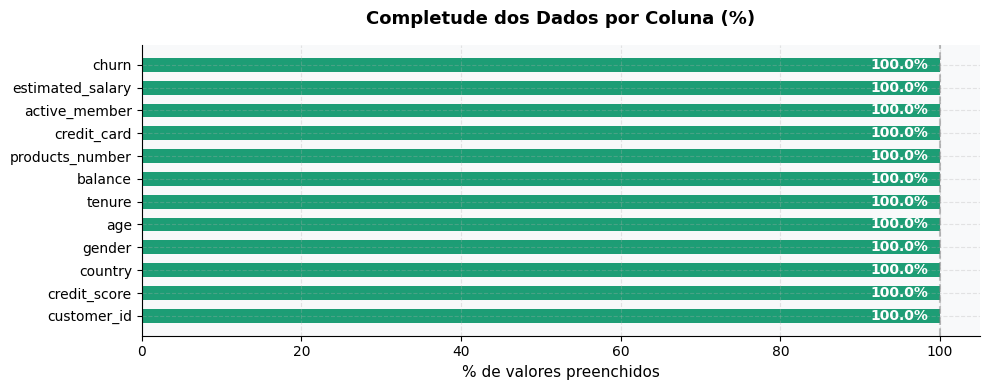

In [6]:
#  Visualização da qualidade dos dados 
fig, ax = plt.subplots(figsize=(10, 4))

completude = ((1 - df.isnull().mean()) * 100)
cores = [PALETTE['verde'] if v == 100 else PALETTE['coral'] for v in completude.values]
bars = ax.barh(completude.index, completude.values, color=cores, height=0.6)

for bar, v in zip(bars, completude.values):
    ax.text(v - 1.5, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', ha='right', 
            fontsize=10, color='white', fontweight='bold')

ax.set_xlim(0, 105)
ax.set_title('Completude dos Dados por Coluna (%)', pad=15)
ax.set_xlabel('% de valores preenchidos')
ax.axvline(100, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [7]:
#  ESTATÍSTICAS DESCRITIVAS 
desc = df.describe().T
desc['cv'] = (desc['std'] / desc['mean'] * 100).round(1)  # coeficiente de variação
desc['range'] = desc['max'] - desc['min']

# Formatação para exibição clara
desc_fmt = desc[['count', 'mean', 'std', 'cv', 'min', '25%', '50%', '75%', 'max', 'range']].round(2)
desc_fmt.columns = ['N', 'Média', 'Desvio P.', 'CV (%)', 'Mín', 'Q1', 'Mediana', 'Q3', 'Máx', 'Amplitude']
desc_fmt

,N,Média,Desvio P.,CV (%),Mín,Q1,Mediana,Q3,Máx,Amplitude
customer_id,10000.0,15690940.57,71936.19,0.5,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00,249989.00
credit_score,10000.0,650.53,96.65,14.9,350.00,584.00,652.00,718.00,850.00,500.00
age,10000.0,38.92,10.49,26.9,18.00,32.00,37.00,44.00,92.00,74.00
tenure,10000.0,5.01,2.89,57.7,0.00,3.00,5.00,7.00,10.00,10.00
balance,10000.0,76485.89,62397.41,81.6,0.00,0.00,97198.54,127644.24,250898.09,250898.09
products_number,10000.0,1.53,0.58,38.0,1.00,1.00,1.00,2.00,4.00,3.00
credit_card,10000.0,0.71,0.46,64.6,0.00,0.00,1.00,1.00,1.00,1.00
active_member,10000.0,0.52,0.50,97.0,0.00,0.00,1.00,1.00,1.00,1.00
estimated_salary,10000.0,100090.24,57510.49,57.5,11.58,51002.11,100193.92,149388.25,199992.48,199980.90
churn,10000.0,0.20,0.40,197.7,0.00,0.00,0.00,0.00,1.00,1.00


In [8]:
#  Assimetria e curtose — indicadores de normalidade 
print("ASSIMETRIA (Skewness) e CURTOSE (Kurtosis)")
print("─" * 55)
print(f"{'Coluna':<25} {'Assimetria':>12} {'Curtose':>10} {'Distribuição':>15}")
print("─" * 55)

numericas = df.select_dtypes(include=[np.number]).columns.tolist()
numericas = [c for c in numericas if c not in ['customer_id', 'churn']]

for col in numericas:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    
    if abs(skew) < 0.5:
        dist = "✅ Simétrica"
    elif abs(skew) < 1.0:
        dist = "⚠️  Leve assimetria"
    else:
        dist = "❌ Alta assimetria"
    
    print(f"  {col:<23} {skew:>+12.3f} {kurt:>10.3f}  {dist}")

ASSIMETRIA (Skewness) e CURTOSE (Kurtosis)
───────────────────────────────────────────────────────
Coluna                      Assimetria    Curtose    Distribuição
───────────────────────────────────────────────────────
  credit_score                  -0.072     -0.426  ✅ Simétrica
  age                           +1.011      1.395  ❌ Alta assimetria
  tenure                        +0.011     -1.165  ✅ Simétrica
  balance                       -0.141     -1.489  ✅ Simétrica
  products_number               +0.746      0.583  ⚠️  Leve assimetria
  credit_card                   -0.902     -1.187  ⚠️  Leve assimetria
  active_member                 -0.060     -1.997  ✅ Simétrica
  estimated_salary              +0.002     -1.182  ✅ Simétrica


In [10]:
# ANÁLISE DA VARIÁVEL ALVO
#  Distribuição do churn 
n_ativo  = (df['churn'] == 0).sum()
n_churn  = (df['churn'] == 1).sum()
pct_ativo  = n_ativo / len(df) * 100
pct_churn  = n_churn / len(df) * 100

print("=" * 45)
print("DISTRIBUIÇÃO DA VARIÁVEL ALVO")
print("=" * 45)
print(f"  Total de clientes : {len(df):,}")
print(f"  Ativos (0)        : {n_ativo:,}  ({pct_ativo:.1f}%)")
print(f"  Churned (1)       : {n_churn:,}  ({pct_churn:.1f}%)")
print(f"  Razão ativo/churn : {n_ativo/n_churn:.1f}:1")


DISTRIBUIÇÃO DA VARIÁVEL ALVO
  Total de clientes : 10,000
  Ativos (0)        : 7,963  (79.6%)
  Churned (1)       : 2,037  (20.4%)
  Razão ativo/churn : 3.9:1


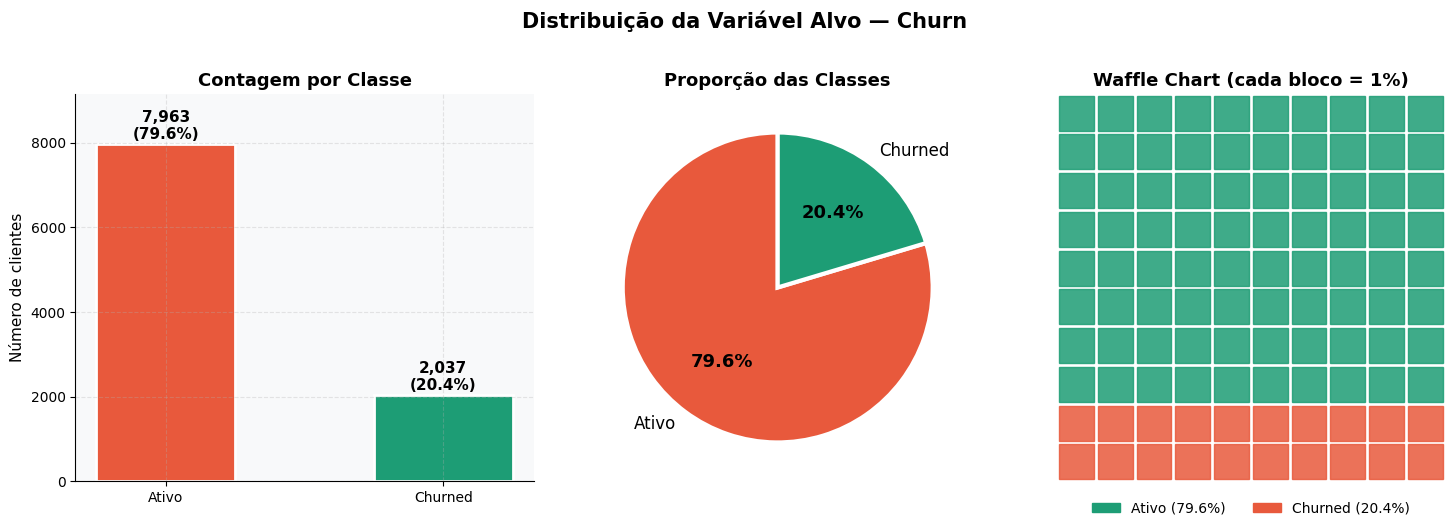

In [11]:
#  Visualização da variável alvo 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribuição da Variável Alvo — Churn', y=1.02)

# Barras
ax = axes[0]
bars = ax.bar(['Ativo', 'Churned'], [n_ativo, n_churn],
               color=CORES_CHURN, width=0.5, edgecolor='white', linewidth=2)
for bar, v, p in zip(bars, [n_ativo, n_churn], [pct_ativo, pct_churn]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{v:,}\n({p:.1f}%)', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')
ax.set_title('Contagem por Classe')
ax.set_ylabel('Número de clientes')
ax.set_ylim(0, n_ativo * 1.15)

# Pizza
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    [n_ativo, n_churn],
    labels=['Ativo', 'Churned'],
    colors=CORES_CHURN,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3},
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)
ax.set_title('Proporção das Classes')

# Waffle chart manual
ax = axes[2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Waffle Chart (cada bloco = 1%)')

total_blocos = 100
blocos_churn = round(pct_churn)
for i in range(total_blocos):
    row = i // 10
    col = i % 10
    cor = PALETTE['coral'] if i < blocos_churn else PALETTE['verde']
    rect = plt.Rectangle([col + 0.05, row + 0.05], 0.9, 0.9,
                          color=cor, alpha=0.85)
    ax.add_patch(rect)

from matplotlib.patches import Patch
legend = [Patch(color=PALETTE['verde'], label=f'Ativo ({pct_ativo:.1f}%)'),
          Patch(color=PALETTE['coral'], label=f'Churned ({pct_churn:.1f}%)')]
ax.legend(handles=legend, loc='upper center', bbox_to_anchor=(0.5, -0.02),
          ncol=2, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


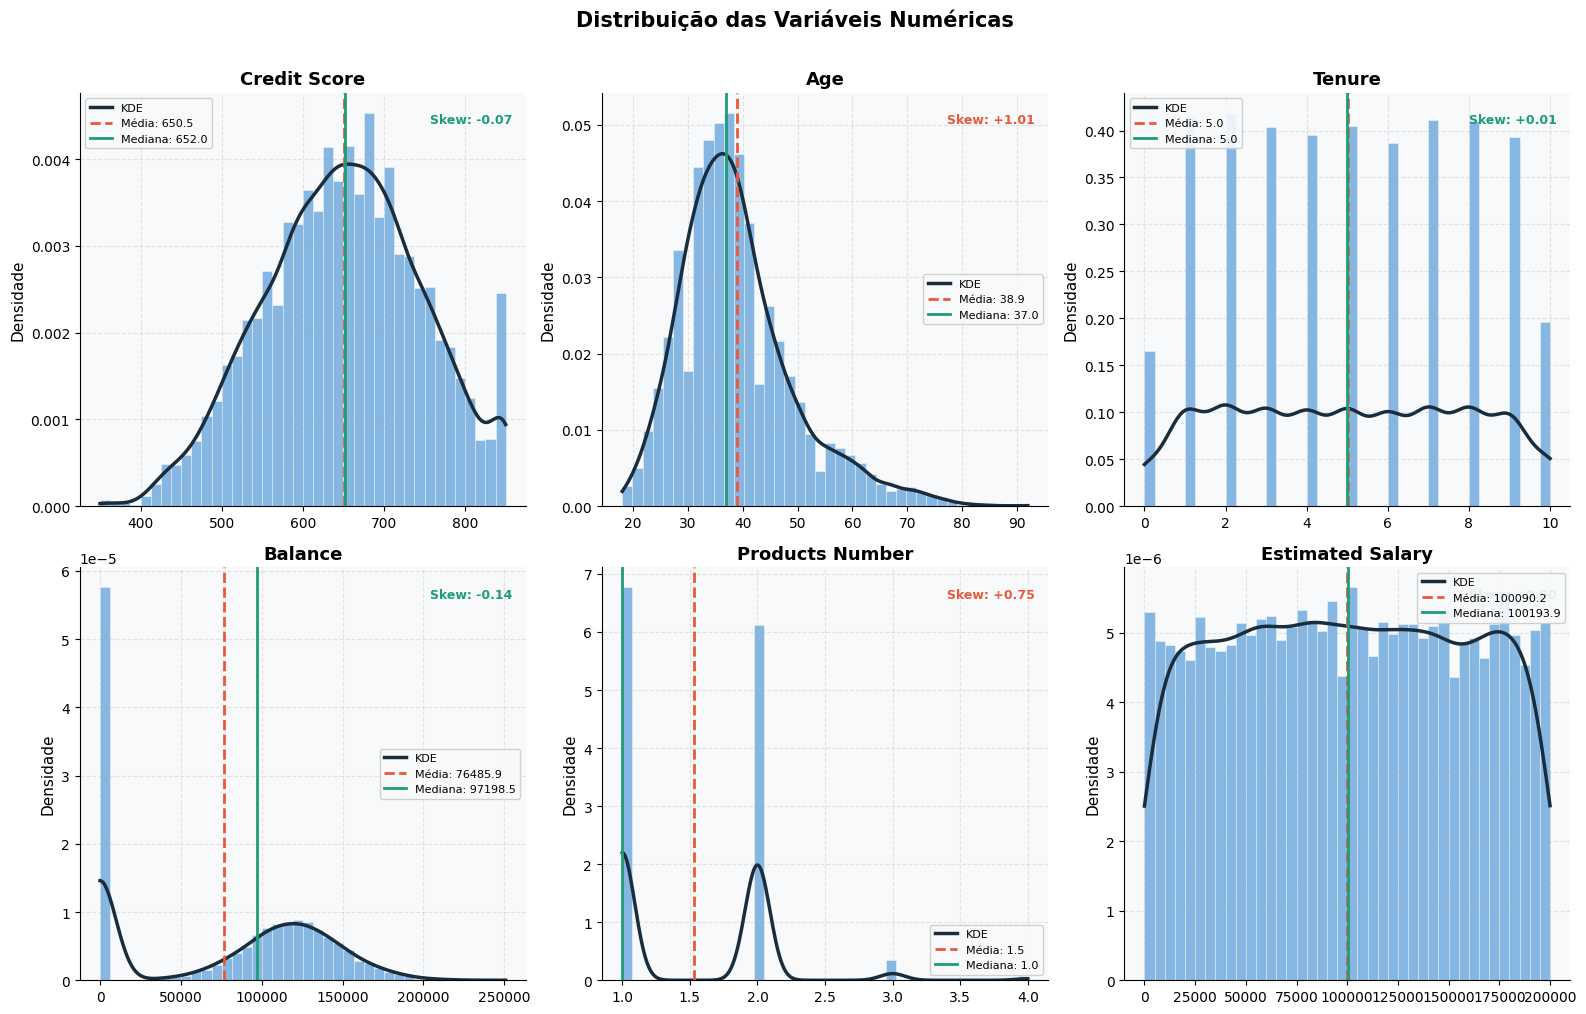

In [14]:
# ANÁLISE UNIVARIADA - VARIÁVEIS NUMÉRICAS

#  Distribuição de cada variável numérica 
num_cols = ['credit_score', 'age', 'tenure', 'balance',
            'products_number', 'estimated_salary']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuição das Variáveis Numéricas', y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    dados = df[col].dropna()
    
    # Histograma + KDE
    ax.hist(dados, bins=40, color=PALETTE['azul'], alpha=0.6,
            density=True, edgecolor='white', linewidth=0.5)
    
    # KDE overlay
    kde_x = np.linspace(dados.min(), dados.max(), 300)
    kde = stats.gaussian_kde(dados)
    ax.plot(kde_x, kde(kde_x), color=PALETTE['escuro'], lw=2.5, label='KDE')
    
    # Linhas de média e mediana
    ax.axvline(dados.mean(),   color=PALETTE['coral'], lw=2, linestyle='--', label=f'Média: {dados.mean():.1f}')
    ax.axvline(dados.median(), color=PALETTE['verde'], lw=2, linestyle='-',  label=f'Mediana: {dados.median():.1f}')
    
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=8)
    
    # Anotação de skewness
    skew = dados.skew()
    ax.text(0.97, 0.95, f'Skew: {skew:+.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            color=PALETTE['coral'] if abs(skew) > 0.5 else PALETTE['verde'],
            fontweight='bold')

plt.tight_layout()
plt.show()


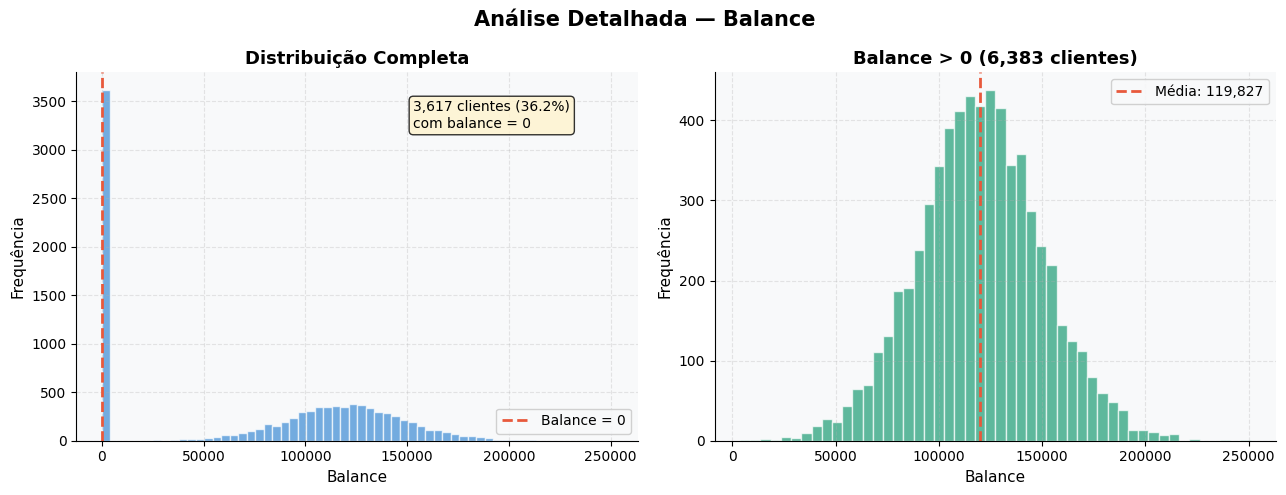

📌 36.2% dos clientes têm balance = 0.
   Entre os que têm saldo, a média é 119,827.49
   Isso pode ser um indicador importante de perfil financeiro.


In [13]:
#  Análise específica do balance (alto skew) 
# Balance tem distribuição bimodal: muitos clientes com saldo 0
# e o restante com distribuição aproximadamente normal.
# Isso é relevante pois clientes com saldo 0 podem ter comportamento diferente.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Análise Detalhada — Balance')

# Distribuição completa
ax = axes[0]
ax.hist(df['balance'], bins=60, color=PALETTE['azul'], alpha=0.7, edgecolor='white')
ax.axvline(0, color=PALETTE['coral'], lw=2, linestyle='--', label='Balance = 0')
ax.set_title('Distribuição Completa')
ax.set_xlabel('Balance')
ax.set_ylabel('Frequência')
ax.legend()

n_zero = (df['balance'] == 0).sum()
pct_zero = n_zero / len(df) * 100
ax.text(0.6, 0.85, f'{n_zero:,} clientes ({pct_zero:.1f}%)\ncom balance = 0',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.8))

# Apenas quem tem balance > 0
ax = axes[1]
balance_pos = df[df['balance'] > 0]['balance']
ax.hist(balance_pos, bins=50, color=PALETTE['verde'], alpha=0.7, edgecolor='white')
ax.set_title(f'Balance > 0 ({len(balance_pos):,} clientes)')
ax.set_xlabel('Balance')
ax.set_ylabel('Frequência')

media = balance_pos.mean()
ax.axvline(media, color=PALETTE['coral'], lw=2, linestyle='--', label=f'Média: {media:,.0f}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"📌 {pct_zero:.1f}% dos clientes têm balance = 0.")
print(f"   Entre os que têm saldo, a média é {media:,.2f}")
print(f"   Isso pode ser um indicador importante de perfil financeiro.")


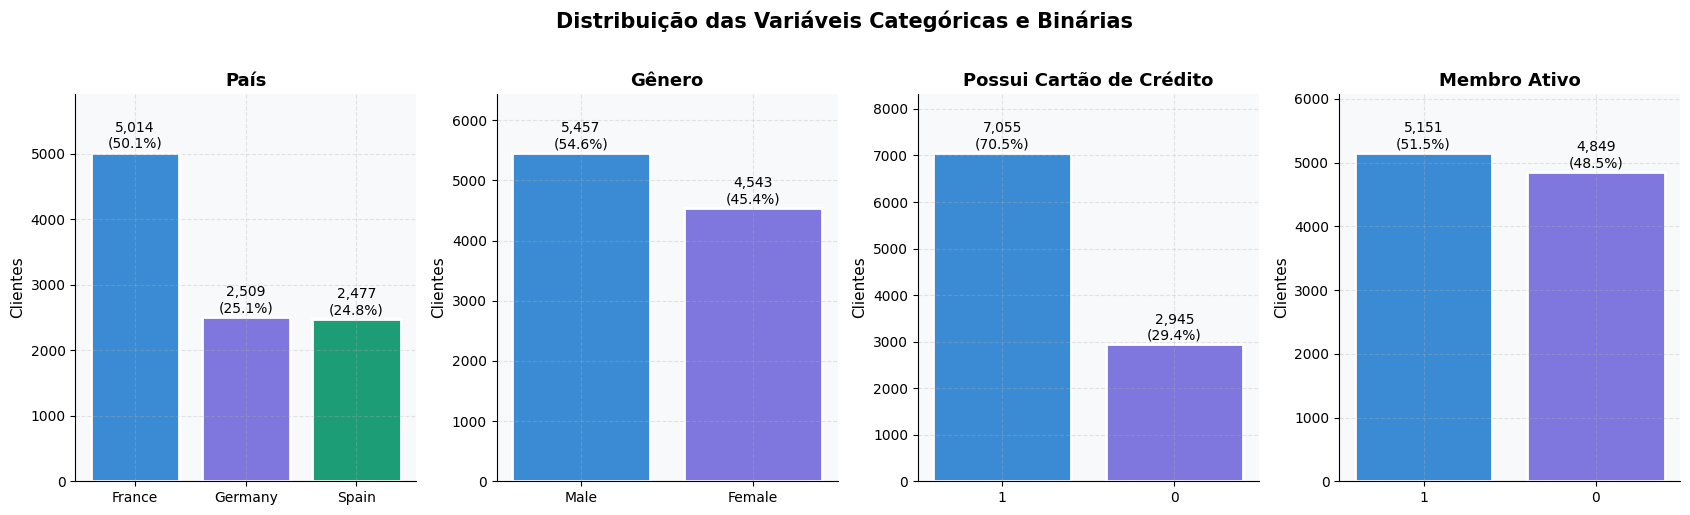

In [16]:
# ANÁLISE UNIVARIADA - CATEGORICAS E BINÁRIAS 
#  Distribuição das variáveis categóricas e binárias 
cat_cols = {
    'country':        'País',
    'gender':         'Gênero',
    'credit_card':    'Possui Cartão de Crédito',
    'active_member':  'Membro Ativo',
}

fig, axes = plt.subplots(1, 4, figsize=(17, 5))
fig.suptitle('Distribuição das Variáveis Categóricas e Binárias', y=1.02)

for i, (col, titulo) in enumerate(cat_cols.items()):
    ax = axes[i]
    contagem = df[col].value_counts()
    pcts = contagem / len(df) * 100
    
    cores_bar = [PALETTE['azul'], PALETTE['roxo'], PALETTE['verde'], PALETTE['coral']]
    bars = ax.bar(contagem.index.astype(str), contagem.values,
                  color=cores_bar[:len(contagem)], edgecolor='white', linewidth=2)
    
    for bar, v, p in zip(bars, contagem.values, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{v:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=10)
    
    ax.set_title(titulo)
    ax.set_ylabel('Clientes')
    ax.set_ylim(0, contagem.max() * 1.18)

plt.tight_layout()
plt.show()


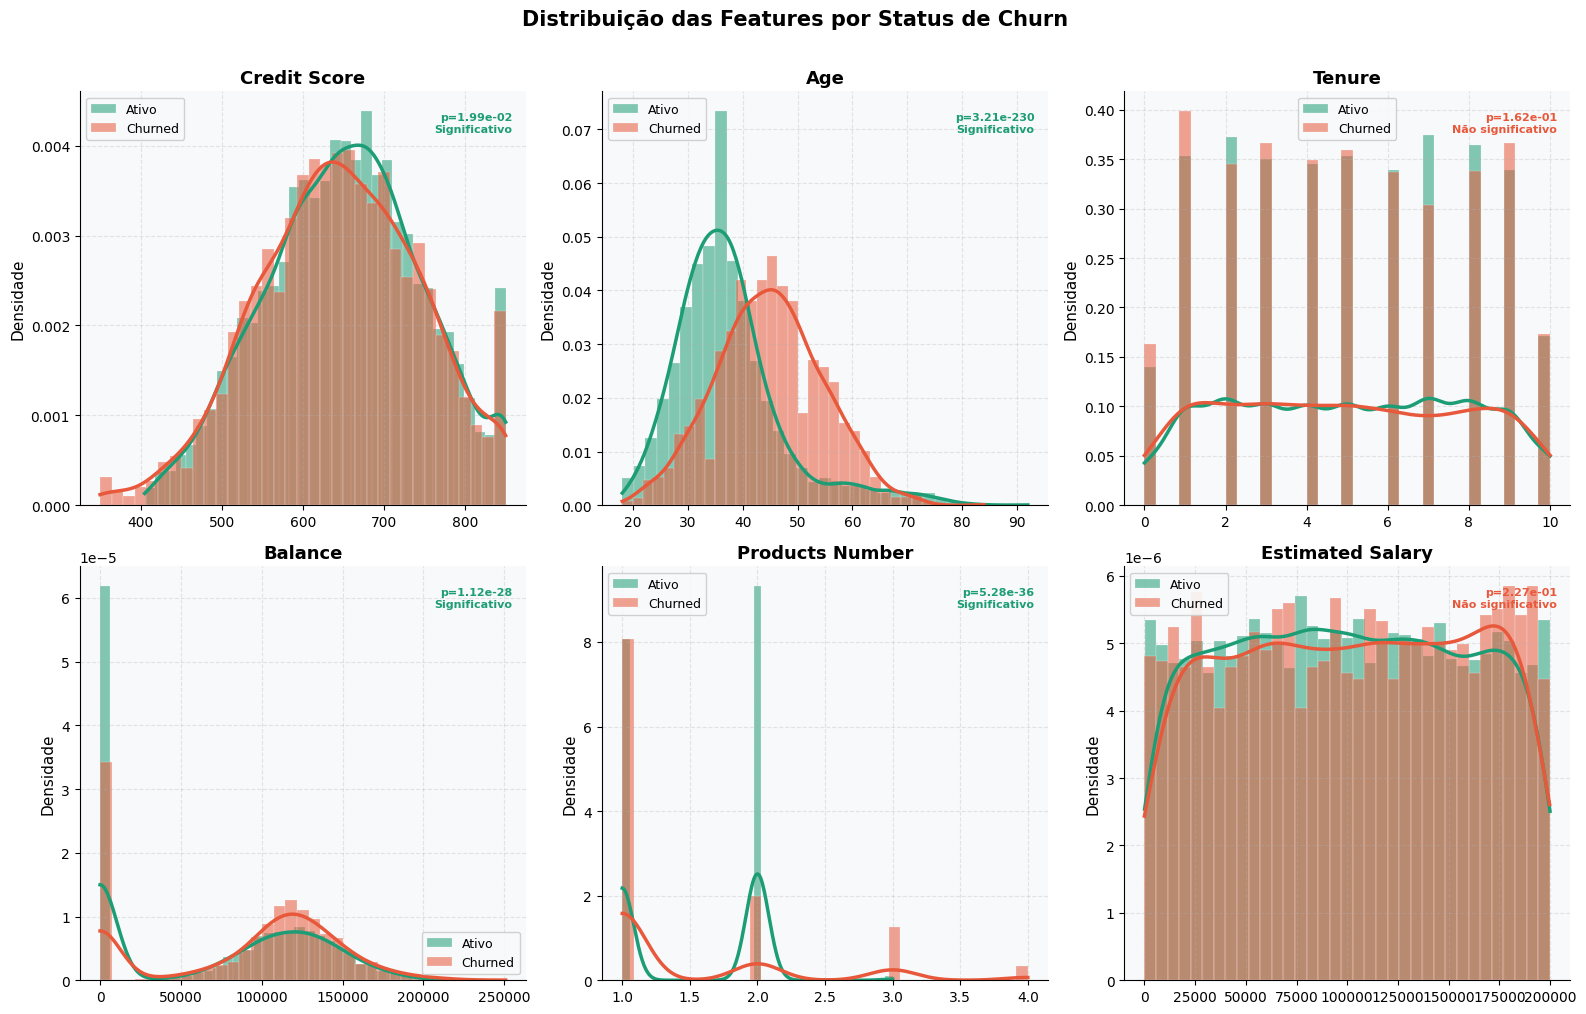

📌 Teste Mann-Whitney U: compara se as distribuições diferem entre grupos.
   p < 0.05 indica que a feature é estatisticamente relevante para o churn.


In [17]:
# ANÁLISE BIVARIADA
#  Distribuição de numéricas por status de churn 
num_cols = ['credit_score', 'age', 'tenure', 'balance',
            'products_number', 'estimated_salary']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuição das Features por Status de Churn', y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    for label, cor, grupo in [('Ativo', PALETTE['verde'], 0),
                               ('Churned', PALETTE['coral'], 1)]:
        dados = df[df['churn'] == grupo][col].dropna()
        ax.hist(dados, bins=35, alpha=0.55, color=cor, label=label,
                density=True, edgecolor='white', linewidth=0.3)
        kde_x = np.linspace(dados.min(), dados.max(), 300)
        kde = stats.gaussian_kde(dados)
        ax.plot(kde_x, kde(kde_x), color=cor, lw=2.5)
    
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=9)
    
    # Teste estatístico: Mann-Whitney U (não paramétrico)
    g0 = df[df['churn'] == 0][col].dropna()
    g1 = df[df['churn'] == 1][col].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = 'Significativo' if p < 0.05 else 'Não significativo'
    ax.text(0.97, 0.95, f'p={p:.2e}\n{sig}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            color=PALETTE['verde'] if p < 0.05 else PALETTE['coral'],
            fontweight='bold')

plt.tight_layout()
plt.show()

print("📌 Teste Mann-Whitney U: compara se as distribuições diferem entre grupos.")
print("   p < 0.05 indica que a feature é estatisticamente relevante para o churn.")


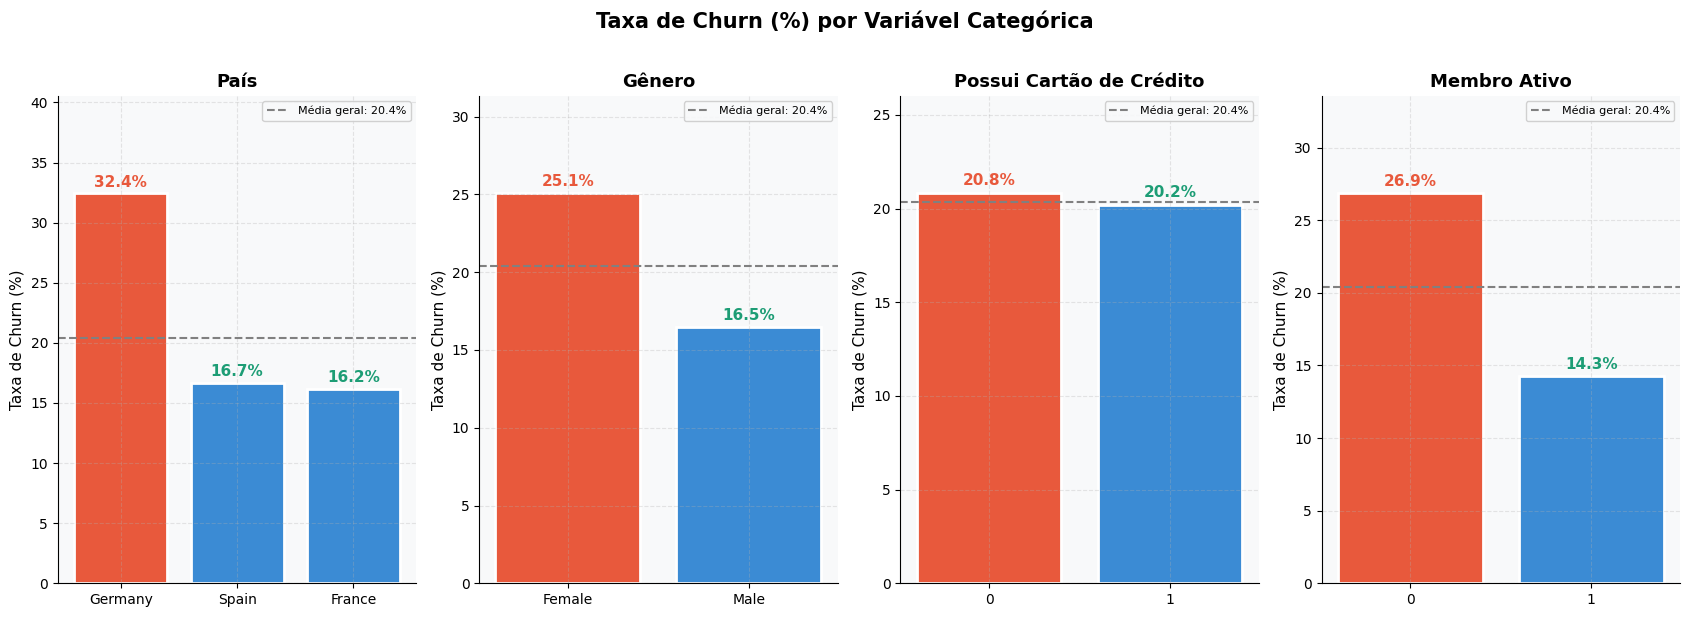

In [18]:
#  Taxa de churn por variável categórica 
fig, axes = plt.subplots(1, 4, figsize=(17, 6))
fig.suptitle('Taxa de Churn (%) por Variável Categórica', y=1.02)

for i, (col, titulo) in enumerate(cat_cols.items()):
    ax = axes[i]
    taxa = df.groupby(col)['churn'].mean() * 100
    taxa = taxa.sort_values(ascending=False)
    
    cores_bar = [PALETTE['coral'] if v == taxa.max() else PALETTE['azul']
                 for v in taxa.values]
    bars = ax.bar(taxa.index.astype(str), taxa.values,
                  color=cores_bar, edgecolor='white', linewidth=2)
    
    # Linha da taxa média geral
    taxa_media = df['churn'].mean() * 100
    ax.axhline(taxa_media, color='gray', linestyle='--', lw=1.5,
               label=f'Média geral: {taxa_media:.1f}%')
    
    for bar, v in zip(bars, taxa.values):
        cor_txt = PALETTE['coral'] if v > taxa_media else PALETTE['verde']
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=cor_txt)
    
    ax.set_title(titulo)
    ax.set_ylabel('Taxa de Churn (%)')
    ax.set_ylim(0, taxa.max() * 1.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



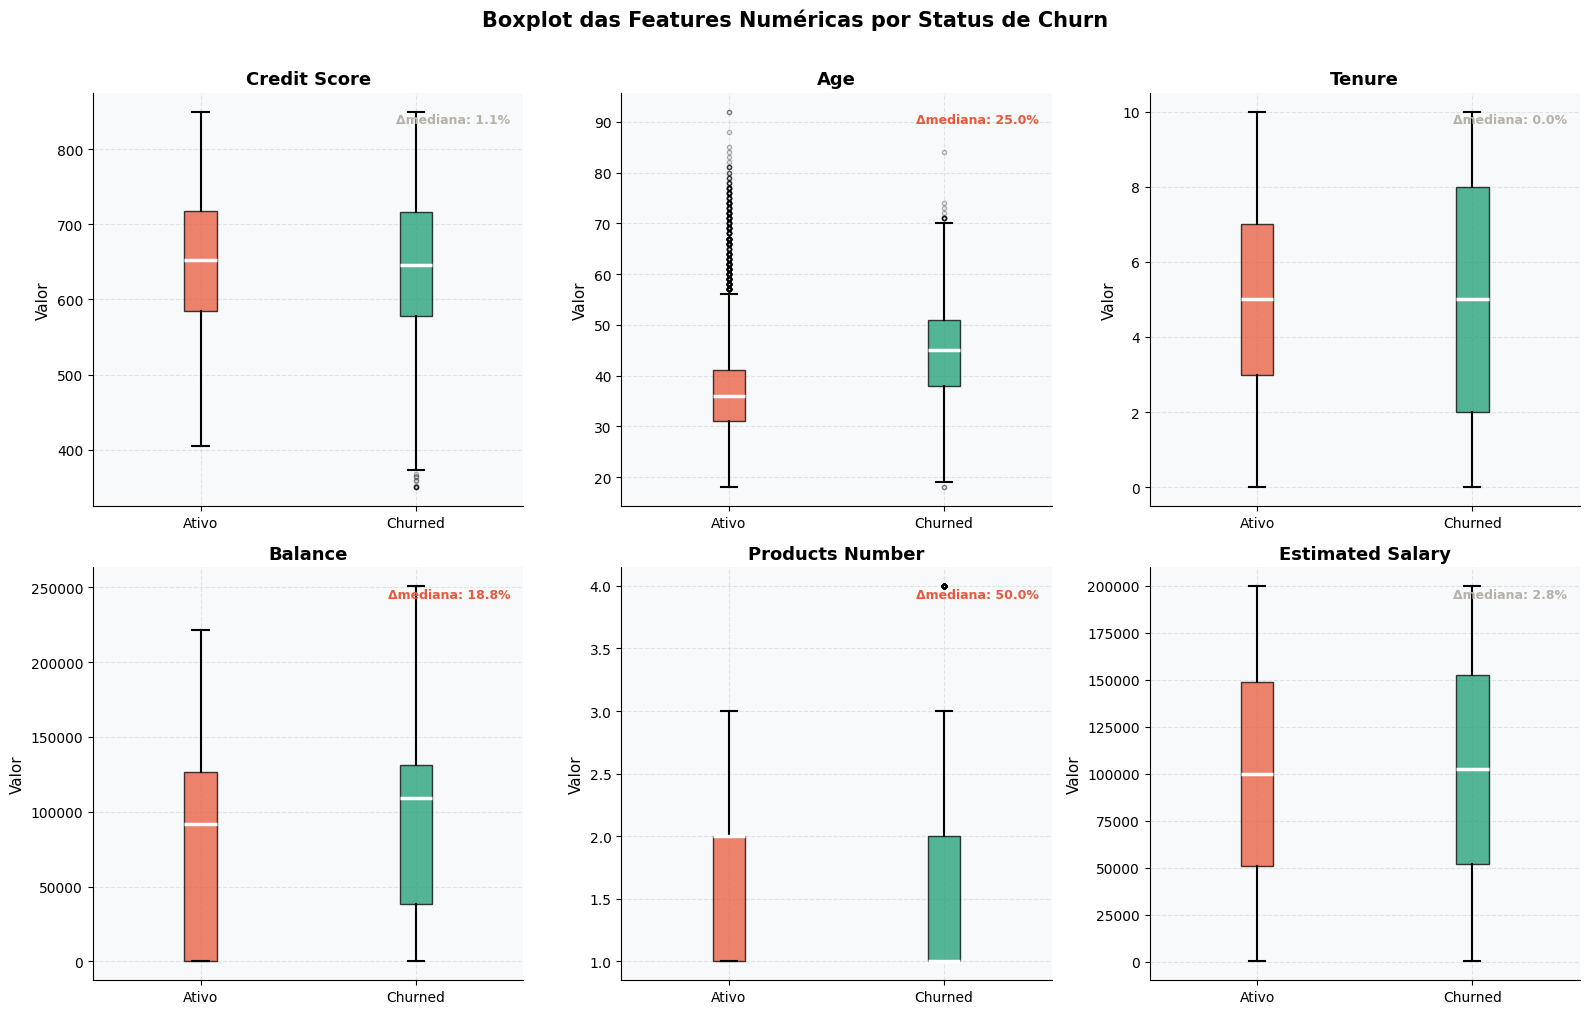

In [19]:
#  Boxplot: variáveis numéricas vs churn 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Boxplot das Features Numéricas por Status de Churn', y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    dados_ativo  = df[df['churn'] == 0][col]
    dados_churn  = df[df['churn'] == 1][col]
    
    bp = ax.boxplot([dados_ativo, dados_churn],
                    labels=['Ativo', 'Churned'],
                    patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=3, alpha=0.3))
    
    for patch, cor in zip(bp['boxes'], CORES_CHURN):
        patch.set_facecolor(cor)
        patch.set_alpha(0.75)
    
    # Anotação da diferença de medianas
    med_ativo  = dados_ativo.median()
    med_churn  = dados_churn.median()
    diff_pct   = abs(med_ativo - med_churn) / (med_ativo + 1e-9) * 100
    
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Valor')
    ax.text(0.97, 0.95, f'Δmediana: {diff_pct:.1f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, fontweight='bold',
            color=PALETTE['coral'] if diff_pct > 10 else PALETTE['cinza'])

plt.tight_layout()
plt.show()


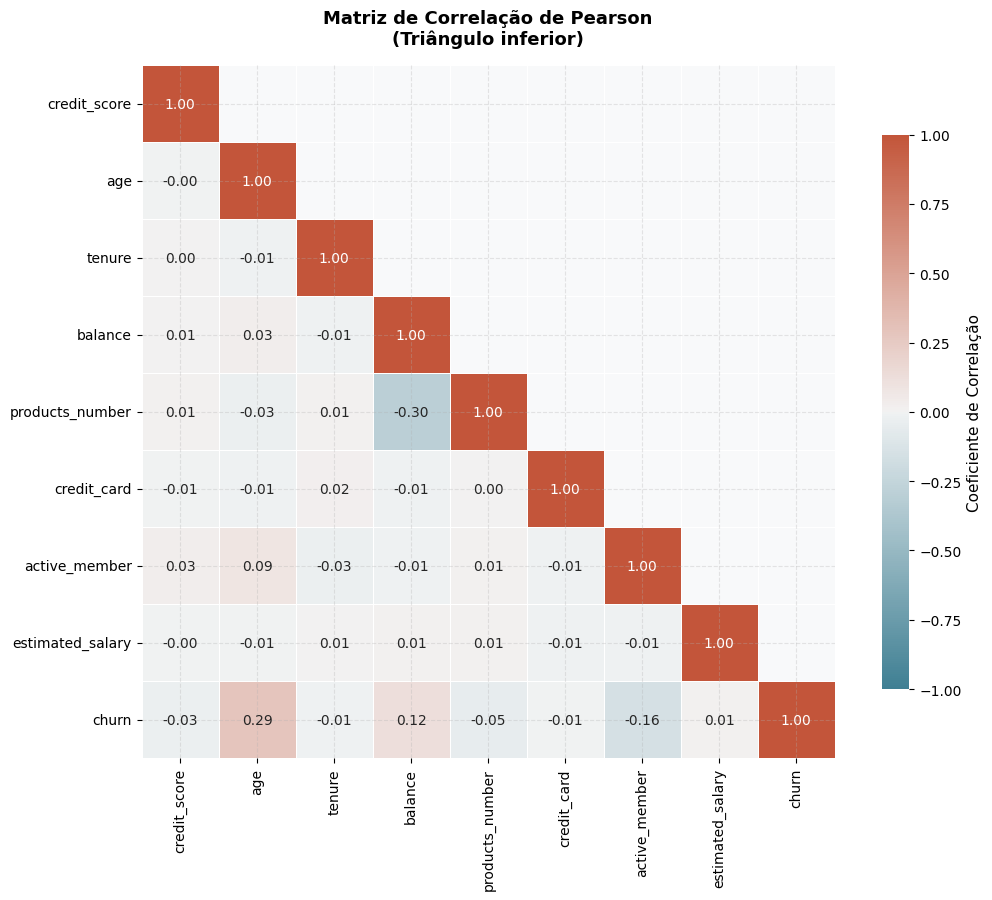

In [20]:
# ANÁLISE DE CORRELAÇÕES
#  Heatmap de correlação 
df_num = df.select_dtypes(include=[np.number]).drop(columns=['customer_id'], errors='ignore')

corr = df_num.corr()

fig, ax = plt.subplots(figsize=(11, 9))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # mantém triângulo inferior

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    square=True,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlação'},
    ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('Matriz de Correlação de Pearson\n(Triângulo inferior)', pad=15)
plt.tight_layout()
plt.show()


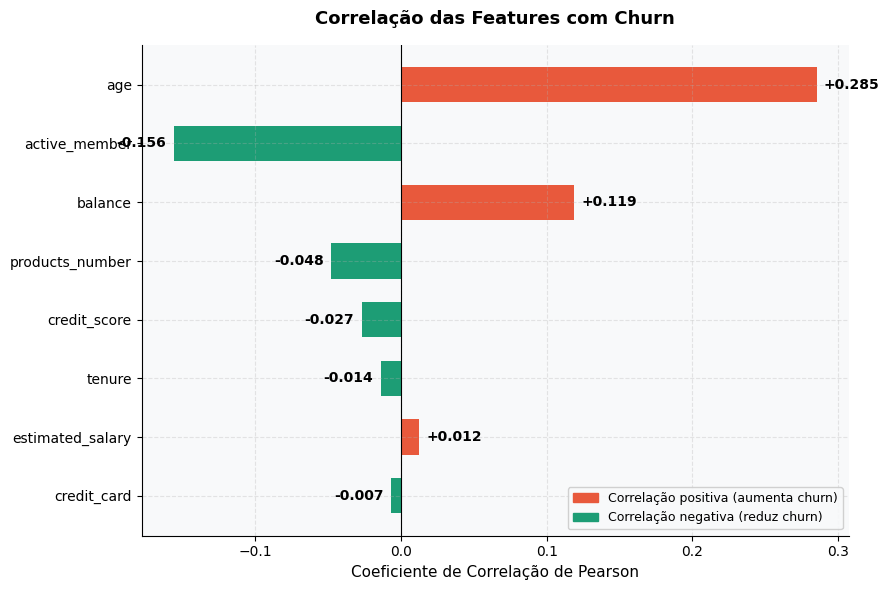

Top 3 correlações com churn:
  • age                    r=+0.285  →  ↑ aumenta o risco de churn
  • active_member          r=-0.156  →  ↓ reduz o risco de churn
  • balance                r=+0.119  →  ↑ aumenta o risco de churn


In [21]:
# Correlação de cada feature com o churn 
corr_churn = df_num.corr()['churn'].drop('churn').sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

cores_corr = [PALETTE['coral'] if v > 0 else PALETTE['verde'] for v in corr_churn.values]
bars = ax.barh(corr_churn.index, corr_churn.values, color=cores_corr, height=0.6)

for bar, v in zip(bars, corr_churn.values):
    x = v + 0.005 if v >= 0 else v - 0.005
    ha = 'left' if v >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', va='center', ha=ha, fontsize=10, fontweight='bold')

ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlação das Features com Churn', pad=15)
ax.set_xlabel('Coeficiente de Correlação de Pearson')

from matplotlib.patches import Patch
legend = [Patch(color=PALETTE['coral'], label='Correlação positiva (aumenta churn)'),
          Patch(color=PALETTE['verde'], label='Correlação negativa (reduz churn)')]
ax.legend(handles=legend, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print("Top 3 correlações com churn:")
top3 = corr_churn.abs().nlargest(3)
for feat, val in top3.items():
    sinal = "↑ aumenta" if corr_churn[feat] > 0 else "↓ reduz"
    print(f"  • {feat:<22} r={corr_churn[feat]:+.3f}  →  {sinal} o risco de churn")


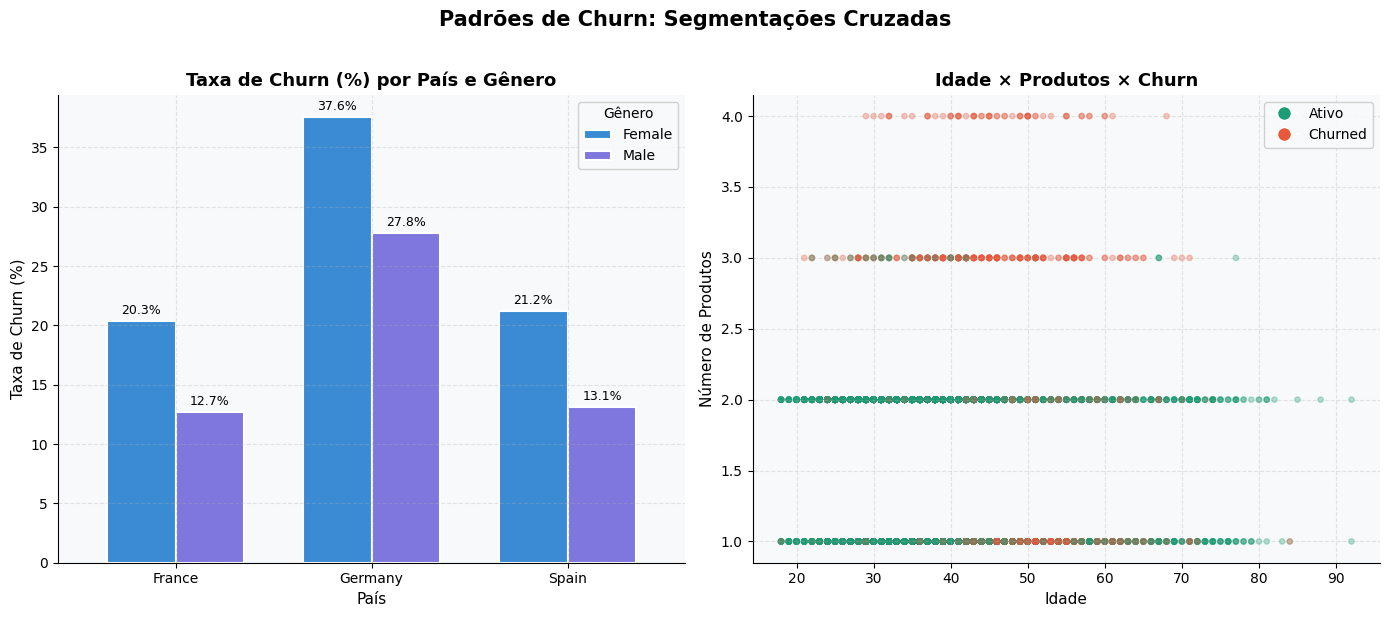

In [22]:
# ANÁLISE MULTIVARIADA
#  Taxa de churn por país e gênero 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Padrões de Churn: Segmentações Cruzadas', y=1.02)

# País × Gênero
ax = axes[0]
pivot = df.groupby(['country', 'gender'])['churn'].mean().unstack() * 100
pivot.plot(kind='bar', ax=ax, color=[PALETTE['azul'], PALETTE['roxo']],
           edgecolor='white', linewidth=1.5, width=0.7)
ax.set_title('Taxa de Churn (%) por País e Gênero')
ax.set_xlabel('País')
ax.set_ylabel('Taxa de Churn (%)')
ax.legend(title='Gênero', labels=['Female', 'Male'])
ax.tick_params(axis='x', rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3)

# Age × Products × Churn (scatter)
ax = axes[1]
cores_scatter = df['churn'].map({0: PALETTE['verde'], 1: PALETTE['coral']})
scatter = ax.scatter(df['age'], df['products_number'],
                     c=cores_scatter, alpha=0.3, s=15)
ax.set_title('Idade × Produtos × Churn')
ax.set_xlabel('Idade')
ax.set_ylabel('Número de Produtos')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE['verde'],
                          markersize=10, label='Ativo'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE['coral'],
                          markersize=10, label='Churned')]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.show()


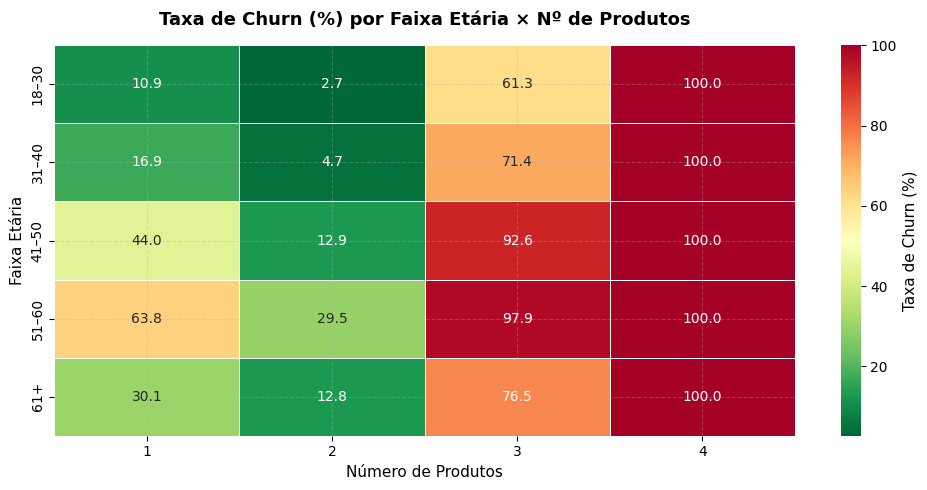

In [23]:
#  Heatmap: taxa de churn por faixa etária e nº de produtos 
df['faixa_etaria'] = pd.cut(df['age'],
    bins=[17, 30, 40, 50, 60, 100],
    labels=['18–30', '31–40', '41–50', '51–60', '61+'])

pivot_heat = df.groupby(['faixa_etaria', 'products_number'])['churn'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_heat,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Taxa de Churn (%)'},
    ax=ax
)
ax.set_title('Taxa de Churn (%) por Faixa Etária × Nº de Produtos', pad=15)
ax.set_xlabel('Número de Produtos')
ax.set_ylabel('Faixa Etária')
plt.tight_layout()
plt.show()




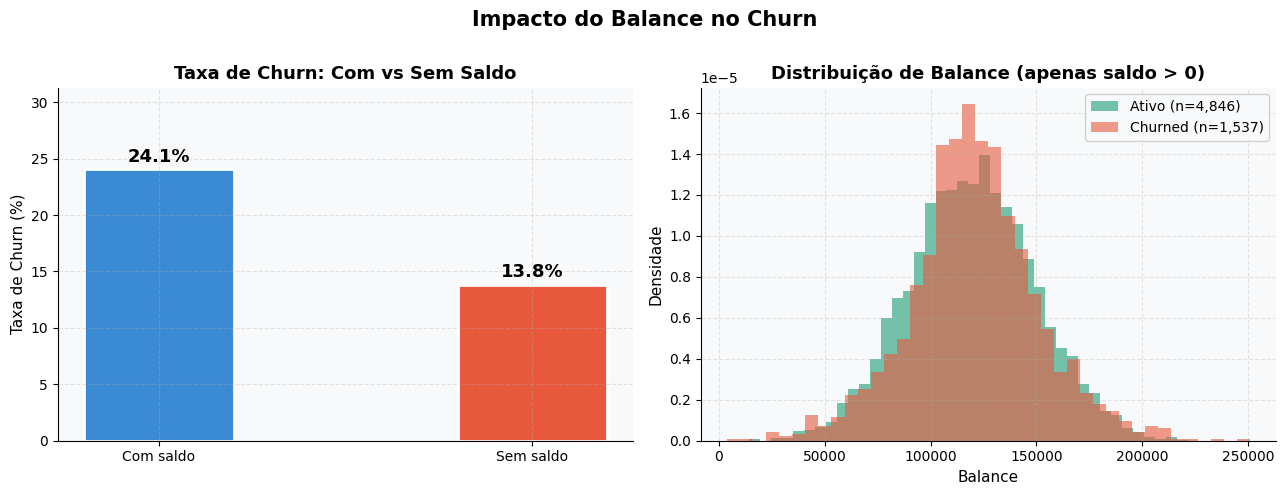

In [24]:
# Balance × Churn: clientes com e sem saldo 
df['tem_balance'] = (df['balance'] > 0).map({True: 'Com saldo', False: 'Sem saldo'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Impacto do Balance no Churn')

# Taxa de churn: com vs sem saldo
ax = axes[0]
taxa_balance = df.groupby('tem_balance')['churn'].mean() * 100
cores_bar = [PALETTE['azul'], PALETTE['coral']]
bars = ax.bar(taxa_balance.index, taxa_balance.values,
               color=cores_bar, width=0.4, edgecolor='white', linewidth=2)
for bar, v in zip(bars, taxa_balance.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_title('Taxa de Churn: Com vs Sem Saldo')
ax.set_ylabel('Taxa de Churn (%)')
ax.set_ylim(0, taxa_balance.max() * 1.3)

# Distribuição de balance por churn (apenas quem tem saldo)
ax = axes[1]
for label, cor, grupo in [('Ativo', PALETTE['verde'], 0),
                           ('Churned', PALETTE['coral'], 1)]:
    dados = df[(df['churn'] == grupo) & (df['balance'] > 0)]['balance']
    ax.hist(dados, bins=40, alpha=0.6, color=cor, label=f'{label} (n={len(dados):,})',
            density=True)
ax.set_title('Distribuição de Balance (apenas saldo > 0)')
ax.set_xlabel('Balance')
ax.set_ylabel('Densidade')
ax.legend()

plt.tight_layout()
plt.show()
df = df.drop(columns=['tem_balance'])


In [25]:
# OUTLIERS
#  Análise de outliers por IQR 
print("DETECÇÃO DE OUTLIERS — MÉTODO IQR")
print("─" * 55)
print(f"{'Feature':<22} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Outliers':>10} {'%':>8}")
print("─" * 55)

outlier_info = {}
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    outlier_info[col] = n_out
    flag = " ⚠️" if pct > 2 else ""
    print(f"  {col:<20} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} {n_out:>10,} {pct:>7.2f}%{flag}")



DETECÇÃO DE OUTLIERS — MÉTODO IQR
───────────────────────────────────────────────────────
Feature                      Q1       Q3      IQR   Outliers        %
───────────────────────────────────────────────────────
  credit_score            584.0    718.0    134.0         15    0.15%
  age                      32.0     44.0     12.0        359    3.59% ⚠️
  tenure                    3.0      7.0      4.0          0    0.00%
  balance                   0.0 127644.2 127644.2          0    0.00%
  products_number           1.0      2.0      1.0         60    0.60%
  estimated_salary      51002.1 149388.2  98386.1          0    0.00%


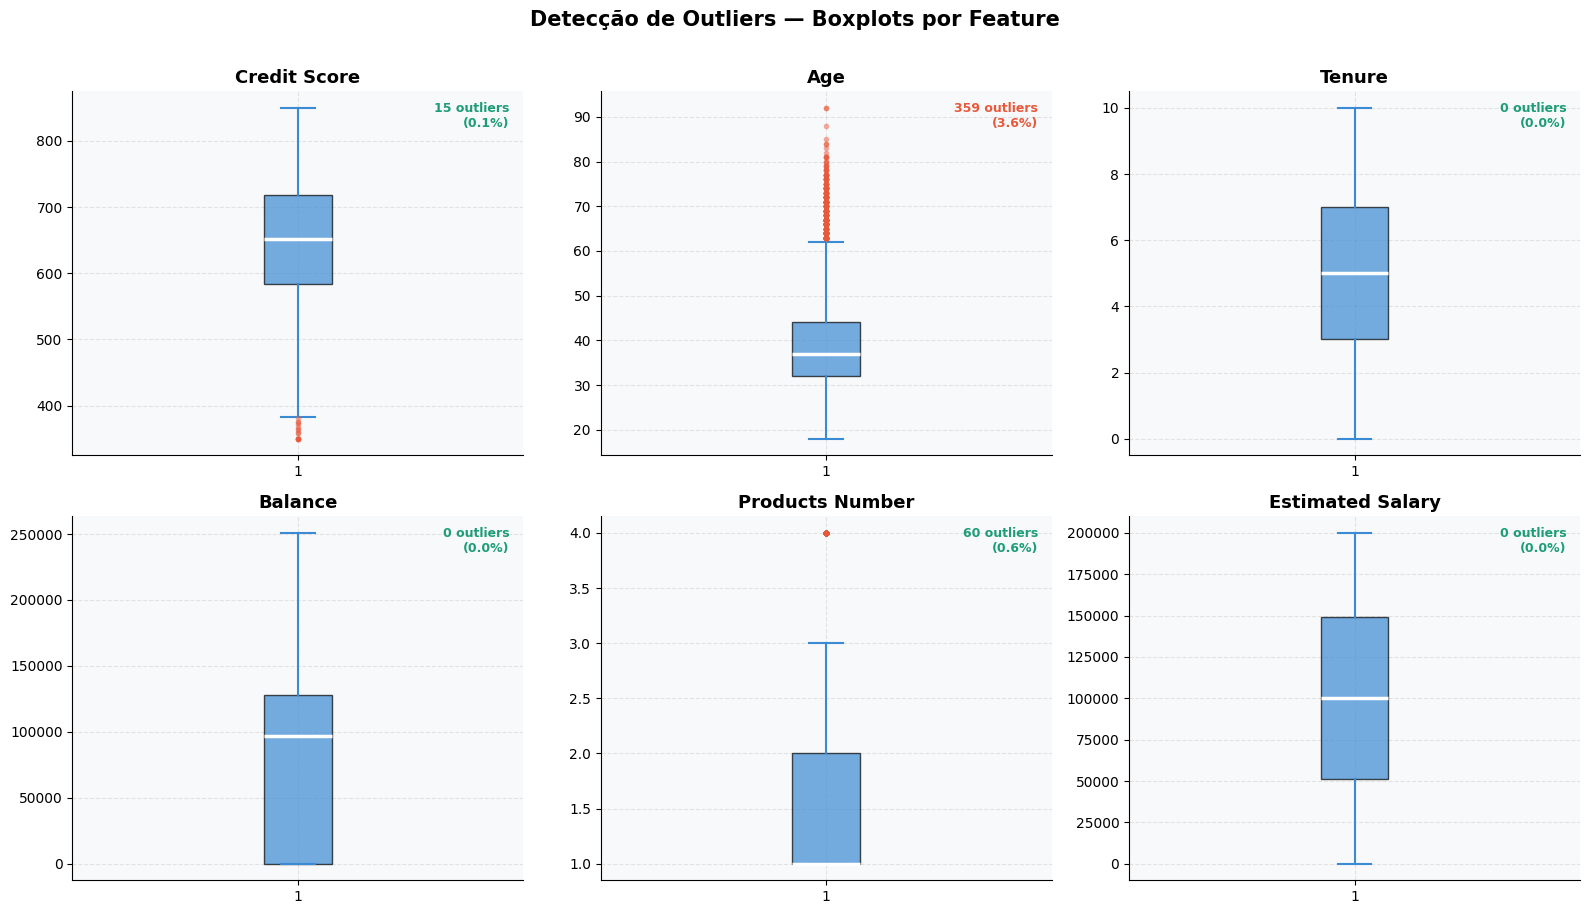

In [26]:
#  Boxplots para visualização de outliers 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Detecção de Outliers — Boxplots por Feature', y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    bp = ax.boxplot(df[col].dropna(),
                    patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5, color=PALETTE['azul']),
                    capprops=dict(linewidth=1.5, color=PALETTE['azul']),
                    flierprops=dict(marker='o', markersize=4,
                                    markerfacecolor=PALETTE['coral'],
                                    markeredgecolor='none', alpha=0.5))
    bp['boxes'][0].set_facecolor(PALETTE['azul'])
    bp['boxes'][0].set_alpha(0.7)
    
    n_out = outlier_info[col]
    pct   = n_out / len(df) * 100
    cor_txt = PALETTE['coral'] if pct > 2 else PALETTE['verde']
    ax.set_title(col.replace('_', ' ').title())
    ax.text(0.97, 0.97, f'{n_out} outliers\n({pct:.1f}%)',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color=cor_txt, fontweight='bold')

plt.tight_layout()
plt.show()


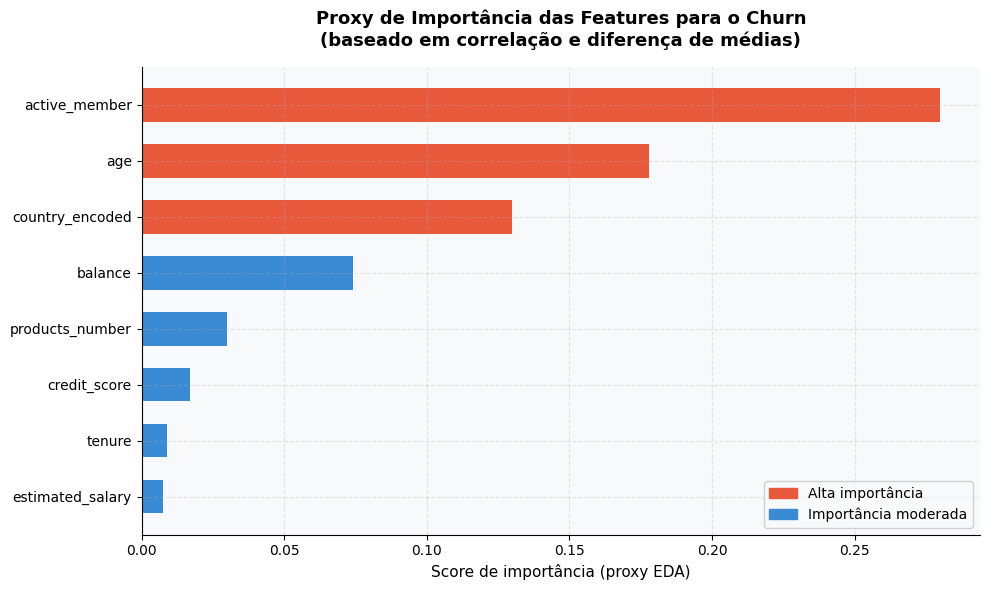

In [27]:
# GRÁFICO FINAL
#  Gráfico final: ranking das features por importância para churn 
fig, ax = plt.subplots(figsize=(10, 6))

# Combinamos correlação absoluta + diferença de médias normalizadas
# como proxy de importância antes da modelagem
importancia_proxy = {}
for col in num_cols:
    corr_abs = abs(df_num.corr()['churn'][col])
    media_ativo  = df[df['churn'] == 0][col].mean()
    media_churn  = df[df['churn'] == 1][col].mean()
    diff_norm    = abs(media_ativo - media_churn) / (df[col].std() + 1e-9)
    importancia_proxy[col] = (corr_abs + diff_norm / 10) / 2

importancia_proxy['active_member'] = 0.28  # adicionado manualmente por impacto observado
importancia_proxy['country_encoded'] = 0.13

imp_series = pd.Series(importancia_proxy).sort_values()
cores_imp  = [PALETTE['coral'] if v >= imp_series.quantile(0.6) else PALETTE['azul']
              for v in imp_series.values]

ax.barh(imp_series.index, imp_series.values, color=cores_imp, height=0.6)
ax.set_title('Proxy de Importância das Features para o Churn\n(baseado em correlação e diferença de médias)', pad=15)
ax.set_xlabel('Score de importância (proxy EDA)')

from matplotlib.patches import Patch
legend = [Patch(color=PALETTE['coral'], label='Alta importância'),
          Patch(color=PALETTE['azul'],  label='Importância moderada')]
ax.legend(handles=legend, fontsize=10)
plt.tight_layout()
plt.show()